# Load QICK

In [82]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from qick.pyro import make_proxy
import Pyro4

from QickworkspaceV2.config.system_cfg import DATA_PATH, config_list
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.core.base_experiment import BaseExperiment
from QickworkspaceV2.experiments_mux import MuxOneTone, MuxPowerRabi, MuxPunchout, MuxRamsey, MuxSingleShotGE, MuxT1, MuxTOF, MuxTwoTone

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
BaseExperiment.setup(soc, soccfg, DATA_PATH)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_bff646b76c5e4e518b71a66a256d98d2@192.168.10.82:35471
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Aug 10 18:48:22 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-

# Instrument connect

In [29]:
from QickworkspaceV2.instruments import BaseInstrumentManager

inst = BaseInstrumentManager()

# Fill these before running. SGS100A/MG3692 accept either plain IP or full VISA string.
# Q1_FLUX_ADDR = "USB0::0x0B21::0x0039::91S522309::INSTR"
# Q2_FLUX_ADDR = ""  # Optional second Yoko; leave empty to skip
MG3692_ADDR = "192.168.10.182"

# Q1_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}
# Q2_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}

# q1_flux = inst.add_yoko(
#     "q1_flux",
#     Q1_FLUX_ADDR,
#     limits=Q1_FLUX_LIMITS,
#     current_ramp_step=1e-8,
#     voltage_ramp_step=1e-5,
#     ramp_interval=0.01,
# )

# q2_flux = None
# if Q2_FLUX_ADDR:
#     q2_flux = inst.add_yoko(
#         "q2_flux",
#         Q2_FLUX_ADDR,
#         limits=Q2_FLUX_LIMITS,
#         current_ramp_step=1e-8,
#         voltage_ramp_step=1e-5,
#         ramp_interval=0.01,
#     )

# lo = inst.add_mg3692("LO", MG3692_ADDR)
# # inst.set_value('LO', 'frequency', 6e9)
# inst.status

In [84]:
config_all = ExperimentConfig(config_list)
config_all.qubit_names()

['Q1', 'Q2', 'Q3', 'Q4']

In [85]:
arm_qubit = ["Q1", "Q3"]

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)

summary_keys = [
    "qubit_names",
    "active_slots",
    "mask",
    "res_ch",
    "ro_chs",
    "active_ro_chs",
    "res_freqs",
    "res_gains",
    "res_phases",
    "ro_phases",
    "qb_ch",
    "qb_freq_ge",
    "pi_gain_ge",
    "mixer_freq",
    "LO_ext",
    "trig_time",
]

for key in summary_keys:
    print(f"{key}: {run_cfg.get(key)}")

qubit_names: ['Q1', 'Q3']
active_slots: [0, 2]
mask: [0, 1, 2, 3]
res_ch: 4
ro_chs: [2, 4]
active_ro_chs: [2, 4]
res_freqs: [716.550099, 740, 815, 890]
res_gains: [0.3, 0, 0.3, 0]
res_phases: [0, 0, 0, 0]
ro_phases: [0, 0, 0, 0]
qb_ch: [0, 0, 2, 0]
qb_freq_ge: [3628.1734969999998, 3620.80596, 3128.8340460000004, 3312.01532]
pi_gain_ge: [0.206313, 0.1, 0.329604, 0.1]
mixer_freq: 766
LO_ext: 6000
trig_time: 0.75


# TOF

The mux mask is fixed to the number of configured qubit slots. Non-armed qubits keep their frequency slot but get zero readout gain.

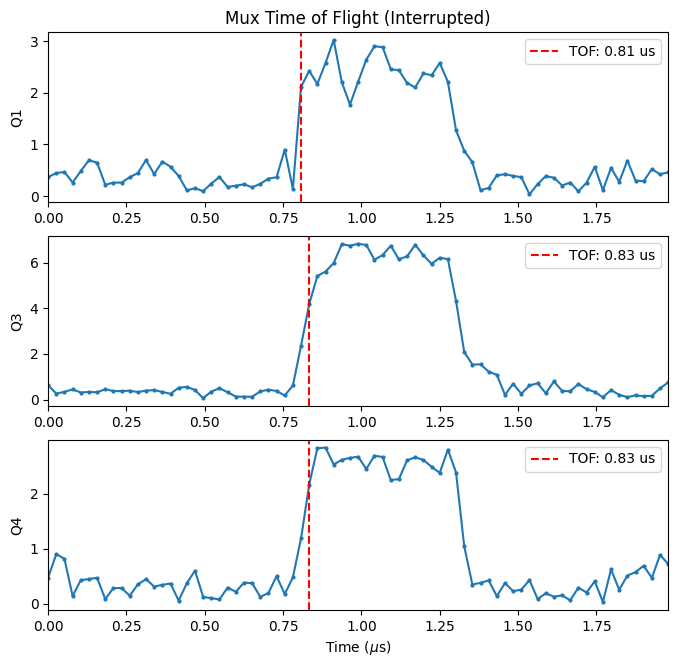

{'Q1': (0.8072916666666667, None),
 'Q3': (0.8333333333333334, None),
 'Q4': (0.8333333333333334, None)}

In [23]:
config_all.update("res_gain_ge", 1)
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6005,
)

run_cfg.update(
    [
        ("res_length", 0.5),
        ("ro_length",2),
        ("relax_delay", 0),
    ]
)
tof = MuxTOF(run_cfg)
# tof.prog_asm()
result = tof.run(py_avg=1000)
result.fit_result

## Mux OneTone

Sweep each active resonator over a 20 MHz span around its configured center frequency.

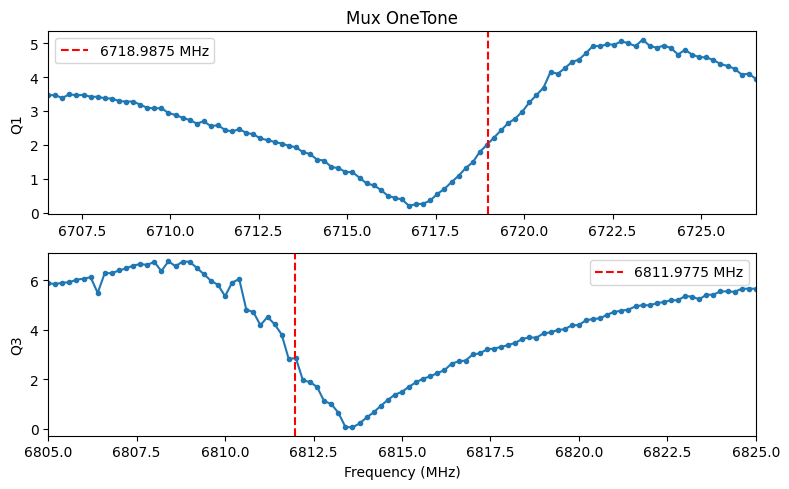

In [86]:
SPAN = 10
STEPS = 101

config_all.update("res_gain_ge", 0.4)
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("res_freq_ge", np.linspace(-SPAN, SPAN, STEPS)),
        ("relax_delay", 0),
    ]
)

onetone = MuxOneTone(run_cfg)
onetone_result = onetone.run(py_avg=3, span=20.0, steps=101, iq_process="abs", plot=True)

f_res = [
    onetone_result.fit_result[f"{q}_res_freq_mhz"][0]
    for q in arm_qubit
]

config_all.update(
    "res_freq_ge",
    f_res,
    q_index=arm_qubit,
)

In [87]:


config_all.update(
    "res_freq_ge",
    6815,
    q_index="Q3",
)

Gain:   0%|          | 0/21 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

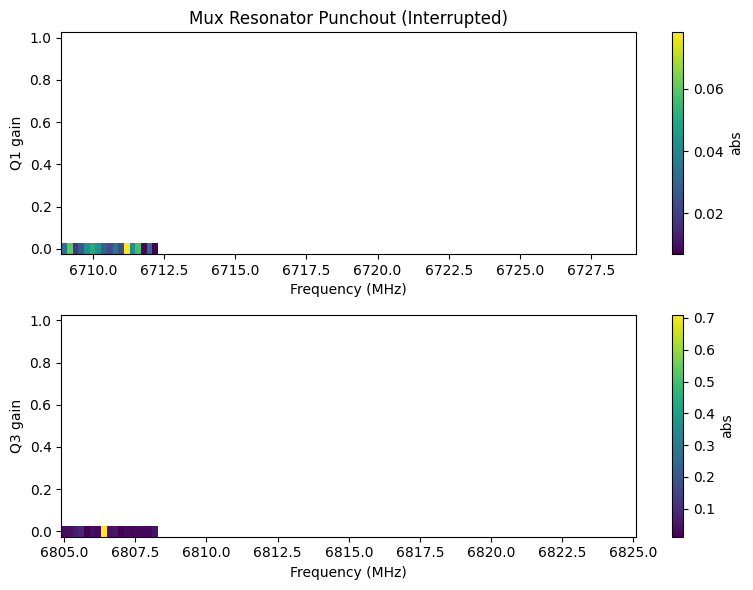

{'status': ('punchout_acquired', None)}

In [88]:
PUNCH_SPAN = 20.0
PUNCH_STEPS = 101
PUNCH_GAINS = np.linspace(0.0, 1.0, 21)

arm_qubit = ["Q1", "Q3"]

config_all.update("res_length", 5)
config_all.update("ro_length", 5)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("relax_delay", 0),
    ]
)

punchout = MuxPunchout(run_cfg)
punchout_result = punchout.run(
    py_avg=5,
    span=PUNCH_SPAN,
    f_steps=PUNCH_STEPS,
    gains=PUNCH_GAINS,
    iq_process="abs",
    plot=True,
)
punchout_result.fit_result

In [6]:


config_all.update(
    "res_freq_ge",
    6817,
    q_index="Q3",
)

## Mux TwoTone

Drive one active qubit at a time while reading out the mux channels.

In [89]:
config_all.update(
    "qb_freq_ge",
    [3620, 3125],
    q_index=arm_qubit,
)

  0%|          | 0/50 [00:00<?, ?it/s]

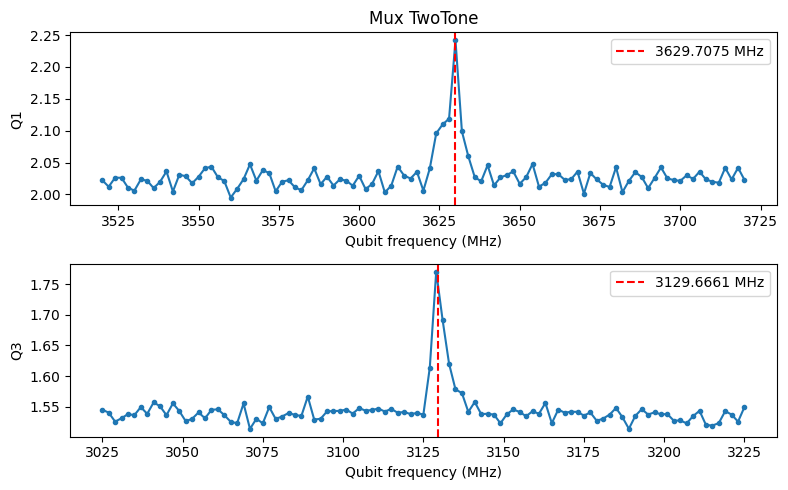

{'Q1_qb_freq_ge_mhz': (3629.707476, None),
 'Q3_qb_freq_ge_mhz': (3129.666071, None)}

In [90]:
START_FREQ = -100
STOP_FREQ = 100
QB_STEPS = 101

arm_qubit = ["Q1", "Q3"]

config_all.update("res_gain_ge", 0.4, q_index=arm_qubit)

config_all.update("qb_ch", [0, 2], q_index=arm_qubit)
config_all.update("qb_gain_ge", 0.3, q_index=arm_qubit)
config_all.update("qb_flat_top_length_ge", 5, q_index=arm_qubit)
config_all.update("pulse_type", "flat_top", q_index=arm_qubit)
config_all.update("sigma_ge", 0.05, q_index=arm_qubit)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_freq", START_FREQ),
        ("stop_freq", STOP_FREQ),
        ("steps", QB_STEPS),
        ("relax_delay", 50),
    ]
)

twotone = MuxTwoTone(run_cfg)
twotone_result = twotone.run(py_avg=50, iq_process="abs", plot=True)
twotone_result.fit_result

In [91]:
f_qb = [
    twotone_result.fit_result[f"{q}_qb_freq_ge_mhz"][0]
    for q in arm_qubit
]

config_all.update(
    "qb_freq_ge",
    f_qb,
    q_index=arm_qubit,
)

## Mux Power Rabi

Sweep qubit drive gain with mux readout on the armed qubits.

  0%|          | 0/50 [00:00<?, ?it/s]

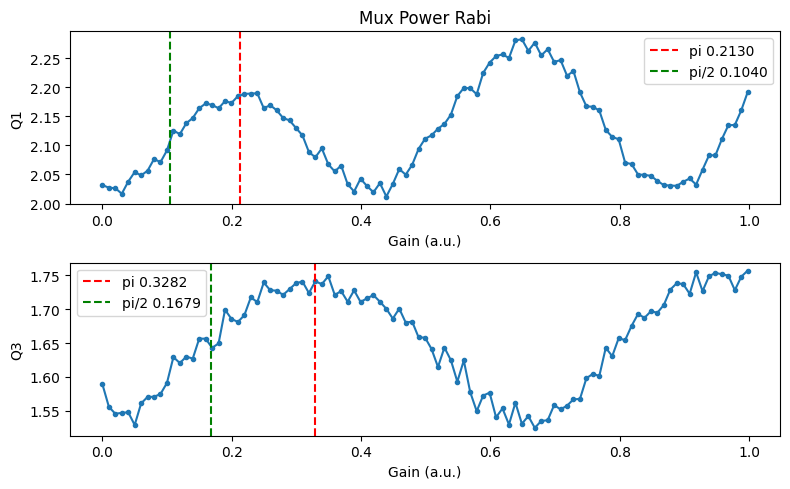

{'Q1_pi_gain': (0.213013, None),
 'Q1_pi2_gain': (0.103972, None),
 'Q3_pi_gain': (0.328157, None),
 'Q3_pi2_gain': (0.167906, None)}

In [92]:
START_GAIN = 0.0
STOP_GAIN = 1.0
GAIN_STEPS = 101

arm_qubit = ["Q1", "Q3"]


config_all.update("pulse_type", "arb", q_index=arm_qubit)
config_all.update("sigma_ge", 0.1, q_index=arm_qubit)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_gain", START_GAIN),
        ("stop_gain", STOP_GAIN),
        ("steps", GAIN_STEPS),
        ("relax_delay", 100),
    ]
)

power_rabi = MuxPowerRabi(run_cfg)
power_rabi_result = power_rabi.run(py_avg=50, iq_process="abs", plot=True)
power_rabi_result.fit_result

In [93]:
pi_gain = [
    power_rabi_result.fit_result[f"{q}_pi_gain"][0]
    for q in arm_qubit
]
pi2_gain = [
    power_rabi_result.fit_result[f"{q}_pi2_gain"][0]
    for q in arm_qubit
]

config_all.update("pi_gain_ge", pi_gain, q_index=arm_qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=arm_qubit)

  0%|          | 0/20 [00:00<?, ?it/s]

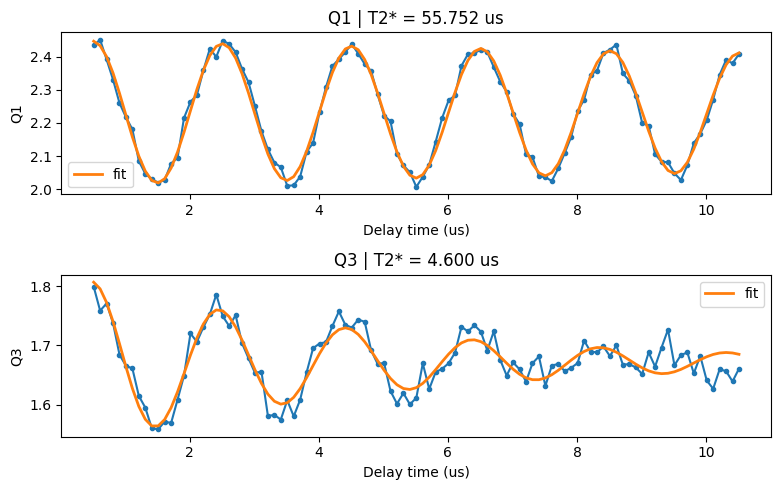

{'Q1_T2r_us': (55.751561, 14.150277312490385),
 'Q1_fit_freq_MHz': (0.49917, 0.0007557160306614558),
 'Q1_detune_MHz': (-0.00083, None),
 'Q1_corrected_freq_MHz': (3628.177476, None),
 'Q3_T2r_us': (4.599989, 0.5081580622695528),
 'Q3_fit_freq_MHz': (0.50847, 0.004049413476220545),
 'Q3_detune_MHz': (0.00847, None),
 'Q3_corrected_freq_MHz': (3128.826071, None)}

In [96]:
START_WAIT = 0.0
STOP_WAIT = 10.0
WAIT_STEPS = 101

arm_qubit = ["Q1", "Q3"]


config_all.update("ramsey_freq", 0.5, q_index=arm_qubit)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_wait", START_WAIT),
        ("stop_wait", STOP_WAIT),
        ("steps", WAIT_STEPS),
        ("relax_delay", 100),
    ]
)

ramsey = MuxRamsey(run_cfg)
ramsey_result = ramsey.run(py_avg=20, iq_process="abs", plot=True)
ramsey_result.fit_result

In [95]:
corrections = ramsey.correct_detune()
update_qubits = [
    q for q in arm_qubit
    if q in corrections and corrections[q]["status"] == "corrected"
]

new_qb_freq = [
    corrections[q]["new_qb_freq_ge"]
    for q in update_qubits
]

if update_qubits:
    config_all.update("qb_freq_ge", new_qb_freq, q_index=update_qubits)

corrections

Q1: detune error +1.53000 MHz, qb_freq_ge -> 3628.17748 MHz
Q3: detune error +0.83000 MHz, qb_freq_ge -> 3128.83607 MHz


{'Q1': {'old_qb_freq_ge': 3629.707476,
  'new_qb_freq_ge': 3628.177476,
  'detune_MHz': 1.530578,
  'ramsey_freq_MHz': 0.5,
  'detune_error_MHz': 1.53,
  'status': 'corrected'},
 'Q3': {'old_qb_freq_ge': 3129.666071,
  'new_qb_freq_ge': 3128.836071,
  'detune_MHz': 0.8308,
  'ramsey_freq_MHz': 0.5,
  'detune_error_MHz': 0.83,
  'status': 'corrected'}}

  0%|          | 0/20 [00:00<?, ?it/s]

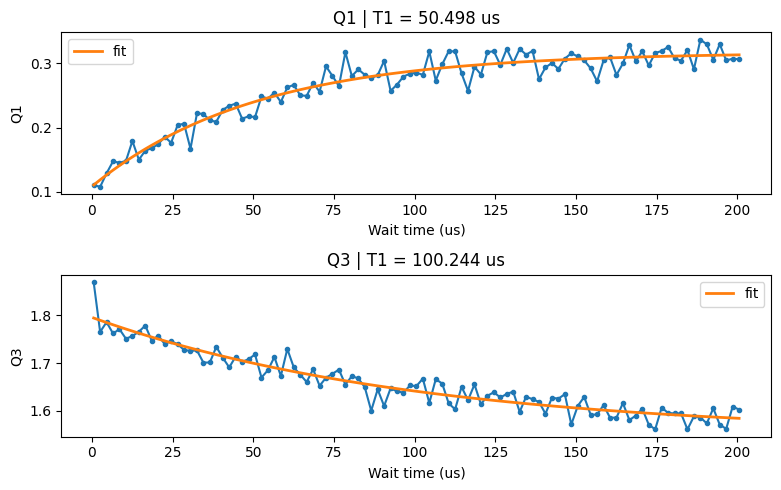

{'Q1_T1_us': (50.498073, None), 'Q3_T1_us': (100.244299, None)}

In [80]:
START_WAIT = 0.0
STOP_WAIT = 200.0
WAIT_STEPS = 101




run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_wait", START_WAIT),
        ("stop_wait", STOP_WAIT),
        ("steps", WAIT_STEPS),
        ("relax_delay", 100),
    ]
)

t1 = MuxT1(run_cfg)
t1_result = t1.run(py_avg=20, iq_process="abs", plot=True)
t1_result.fit_result

  0%|          | 0/5000 [00:00<?, ?it/s]

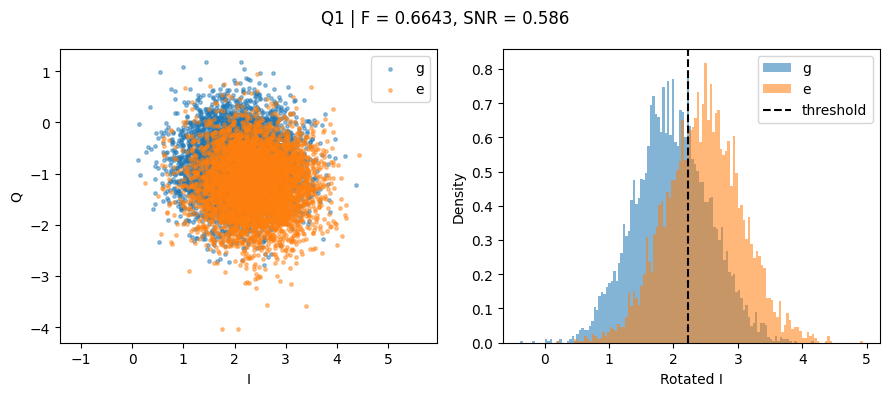

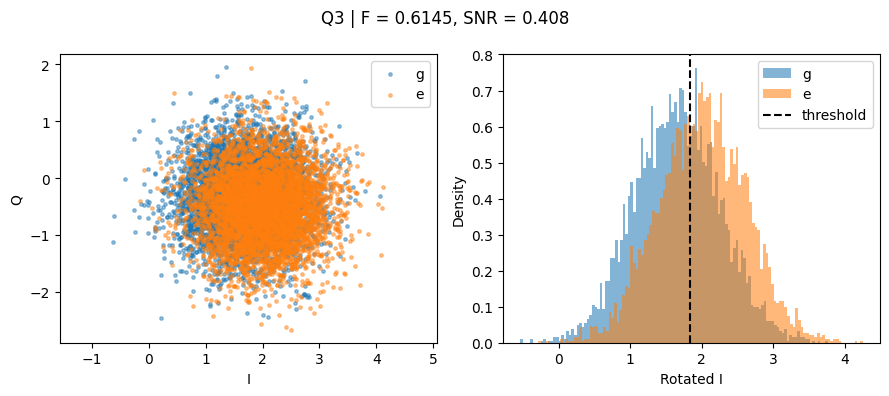

{'Q1_fidelity': (0.6643, None),
 'Q1_threshold': (2.224587, None),
 'Q1_rotation_deg': (48.476917, None),
 'Q1_snr': (0.58577, None),
 'Q3_fidelity': (0.6145, None),
 'Q3_threshold': (1.830575, None),
 'Q3_rotation_deg': (26.885616, None),
 'Q3_snr': (0.407783, None)}

In [100]:
SHOTS = 5000


config_all.update("res_gain_ge", 1, q_index=arm_qubit)
config_all.update("res_length", 10)
config_all.update("ro_length", 8)


run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("shots", SHOTS),
        ("relax_delay", 500),
    ]
)

single_shot = MuxSingleShotGE(run_cfg)
single_shot_result = single_shot.run(plot=True)
single_shot_result.fit_result